In [1]:
#!/usr/bin/env python3
import numpy as np
import os,sys,glob
from pathlib import Path
import tqdm
import logging
from helper import (filterObjects,getModelInfo,saveOutput, \
                    overlapRemoval, minDphilist, eff_trigger, \
                    getLLPDecayRadius,getLLPDecayTime,electronPtSmear,\
                    eff_track_EWK,eff_track_Strong, cutFlow)
from numpy import ndarray
from typing import Any, Dict, List, Tuple, Union
import multiprocessing
import subprocess
from computeEfficiencies import getObjects,preSelection

FORMAT = '%(levelname)s: %(message)s'
logging.basicConfig(format=FORMAT,datefmt='%m/%d/%Y %I:%M:%S %p')
logger = logging.getLogger()   

# Fix seed so results are reproducible!
np.random.seed(seed=123)

DelphesLLP_path = Path(os.path.abspath("./DelphesLLP"))
os.environ['ROOT_INCLUDE_PATH'] = os.path.join(DelphesLLP_path,"external")

import ROOT
ROOT.gSystem.Load(os.path.join(DelphesLLP_path,"libDelphes.so"))
ROOT.gInterpreter.Declare('#include "classes/SortableObject.h"')
ROOT.gInterpreter.Declare('#include "classes/DelphesClasses.h"')
ROOT.gInterpreter.Declare('#include "external/ExRootAnalysis/ExRootTreeReader.h"')
from ROOT import TFile,Electron, Jet, MissingET, Muon, TTree


# Define SRs and Cutflow
ewk_cutflow = cutFlow(name='EWK_cutflow',levels=['All', 'GRL and Cleaning', 'MET Trigger', 'Lepton Veto', 
                    'MET > 200 GeV', 'Jet pT > 100 GeV', 'min(DeltaPhi(JetMET)) > 1.0'])
strong_cutflow = cutFlow(name='Strong_cutflow',levels=['All', 'GRL and Cleaning', 'MET Trigger', 'Lepton Veto',
                      'MET > 250 GeV', 'Jet pT > 100,20,20 GeV', 'min(DeltaPhi(JetMET)) > 0.4'])
ewk_SR = cutFlow(name='EWK_SR',levels=['All', 'Kinematic', 'Tracklet Emulation', 'Leading tracklet',
                                'DeltaR(jet) > 0.4', 'DeltaR(electron) > 0.4', 'DeltaR(muon) > 0.4',
                                 '0.1 < Eta < 1.9'])
strong_SR = cutFlow(name='Strong_SR',levels=['All', 'Kinematic', 'Tracklet Emulation', 'Leading tracklet',
                                'DeltaR(jet) > 0.4', 'DeltaR(electron) > 0.4', 'DeltaR(muon) > 0.4',
                                 '0.1 < Eta < 1.9'])

Welcome to JupyROOT 6.30/06


In [2]:
tauList  = [0.3,0.01]
# inputFile = './run_113/wino_100GeV_0.300ns_delphes_events.root'
inputFile = './pp2chgchg_test0/Events/run_01/wino_100GeV_0.300ns_delphes_events.root'
ijob = -1
tau0 = 0.3

In [8]:
tauList = np.array(tauList)
eff_SR = cutFlow(name="Efficiencies",levels=['EWK SR', 'Strong SR'],
                    zero_weight=np.zeros(len(tauList)))

f = TFile(inputFile,'read')
DelphesTree = f.Get('Delphes')
nevts = DelphesTree.GetEntries()

totalweight = 0
ct=0

llp_effs = []
ewk_weights = []
llp_Rs = []
llp_pTs = []
weights = []


disable = False
if ijob < 0:
    disable = True
for entry in tqdm.tqdm(range(nevts),position=ijob,
                        desc=inputFile,
                        leave=False,
                        disable=disable):
    DelphesTree.GetEntry(entry)
    weight = DelphesTree.Weight.At(0).Weight
    weights.append(weight)
    ct+=1
    #weight = float(DelphesTree.Weight.At(0).Weight)
    #weight = 1.0
    totalweight += weight
    llps,muons,electrons,jets,met = getObjects(DelphesTree)
    pts = [0.0,0.0]
    for llp in llps:
        if llp.PID == 1000024:
            illp = 0
        elif llp.PID == -1000024:
            illp = 1
        else:
            print(f'wrong LLP ID = {llp.PID}')
            raise ValueError()
        pts[illp] = llp.PT
    llp_pTs.append(pts)
#End of loop
f.Close()

In [11]:
print(totalweight/25000)

9.442418661804199


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']
cm_rev = plt.colormaps['RdYlBu_r']

In [6]:
# ewk_weights = np.array(ewk_weights)
# llp_effs = np.array(llp_effs)
llp_pTs = np.array(llp_pTs)
# print(ewk_weights.shape,llp_effs.shape)

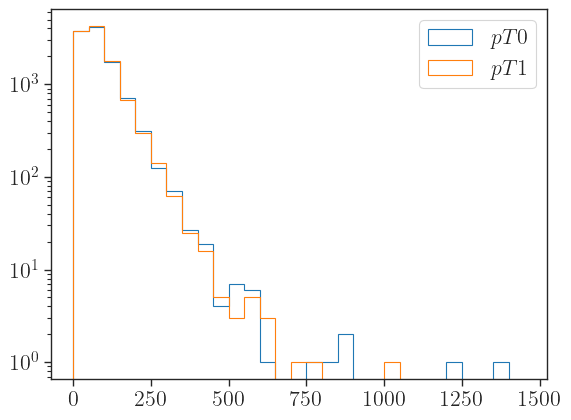

In [7]:
plt.hist(llp_pTs[:,0],label=r'$pT0$',bins=np.arange(0.,1500.,50.),histtype='step')
plt.hist(llp_pTs[:,1],label=r'$pT1$',bins=np.arange(0.,1500.,50.),histtype='step')
plt.legend()
# plt.xscale('log')
plt.yscale('log')
plt.show()
